# Modelado Supervisado — OSMI Mental Health in Tech Survey

**Objetivo:** Predecir si una persona del sector tecnológico buscará tratamiento profesional para un problema de salud mental, a partir de características laborales, demográficas y de actitud hacia la salud mental.

**Variable objetivo:** `Have you ever sought treatment for a mental health issue from a mental health professional?` 

(binaria: 1 = sí buscó tratamiento, 0 = no)

**Modelos evaluados:**
1. Regresión Logística
2. Random Forest
3. K-Nearest Neighbors (KNN)

---

## 1. Importación de librerías

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression # Regresion logistica
from sklearn.ensemble import RandomForestClassifier # Random forest
from sklearn.neighbors import KNeighborsClassifier # KNN
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 2. Carga de datos

Se utiliza el dataset resultante del proceso de feature engineering (`mental_health_feature_engineering.csv`), que ya contiene variables numéricas codificadas y features derivadas como `indice_apoyo_institucional` y `grupo_edad`.

In [9]:
df = pd.read_csv(r'mental_health_feature_engineering.csv')
print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (1243, 46)


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,...,gender_Other,region_Africa,region_Asia,region_Europe,region_Latin America,region_North America,region_Oceania,region_Other,grupo_edad,indice_apoyo_institucional
0,0,2,1,-1,0,0,0,-1,5,0,...,0,0,0,1,0,0,0,0,2,-2
1,0,1,1,0,2,2,2,2,4,0,...,0,0,0,0,0,1,0,0,1,6
2,0,1,1,0,0,0,0,-1,3,1,...,0,0,0,1,0,0,0,0,2,-1
3,1,-1,-1,-1,0,-1,-1,-1,-1,-1,...,0,0,0,1,0,0,0,0,2,-4
4,0,1,0,2,2,0,0,0,3,2,...,0,0,0,0,0,1,0,0,2,2


In [ ]:
# Se elimina la variable mas influyente segun Random forest
# ESTA CELDA PUEDE SER ELIMINADA
df = df.drop(columns='Do you have a family history of mental illness?')
df.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,...,gender_Other,region_Africa,region_Asia,region_Europe,region_Latin America,region_North America,region_Oceania,region_Other,grupo_edad,indice_apoyo_institucional
0,0,2,1,-1,0,0,0,-1,5,0,...,0,0,0,1,0,0,0,0,2,-2
1,0,1,1,0,2,2,2,2,4,0,...,0,0,0,0,0,1,0,0,1,6
2,0,1,1,0,0,0,0,-1,3,1,...,0,0,0,1,0,0,0,0,2,-1
3,1,-1,-1,-1,0,-1,-1,-1,-1,-1,...,0,0,0,1,0,0,0,0,2,-4
4,0,1,0,2,2,0,0,0,3,2,...,0,0,0,0,0,1,0,0,2,2


## 3. Definición del problema

Se trata de un problema de **clasificación binaria supervisada**:
- **Clase 1:** La persona buscó tratamiento profesional para salud mental
- **Clase 0:** La persona no buscó tratamiento

Se verifica la distribución de la variable objetivo para evaluar balance de clases.

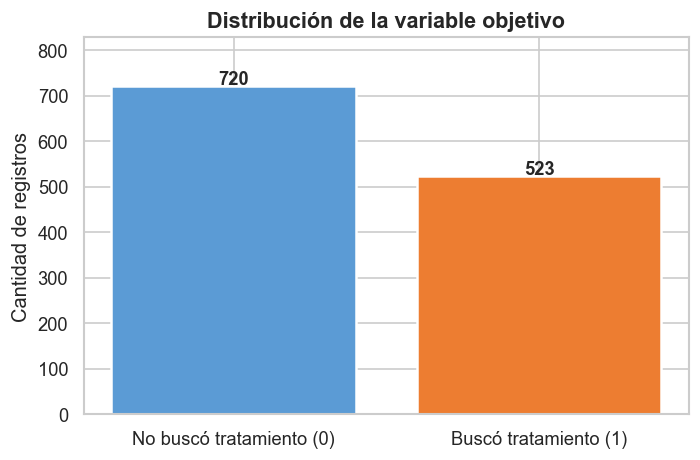

Clase 0: 523 registros (42.1%)
Clase 1: 720 registros (57.9%)


In [11]:
TARGET = 'Have you ever sought treatment for a mental health issue from a mental health professional?'

conteo = df[TARGET].value_counts()
etiquetas = ['No buscó tratamiento (0)', 'Buscó tratamiento (1)']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(etiquetas, conteo.values, color=['#5B9BD5', '#ED7D31'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribución de la variable objetivo', fontsize=13, fontweight='bold')
ax.set_ylabel('Cantidad de registros')
ax.set_ylim(0, max(conteo.values) * 1.15)
plt.tight_layout()
plt.show()

print(f'Clase 0: {conteo[0]} registros ({conteo[0]/len(df)*100:.1f}%)')
print(f'Clase 1: {conteo[1]} registros ({conteo[1]/len(df)*100:.1f}%)')

## 4. Preparación de datos para el modelado

Se separa la variable objetivo del conjunto de features, y se aplica `stratify=y` en la división para mantener la proporción de clases en train y test.

In [12]:
X = df.drop(columns=[TARGET]) # Se separan las variables independientes
y = df[TARGET].astype(int) # Se toma la variable dependiente

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros') # Aqui sabemos cuantos registros tenemos de cada grupo
print(f'Proporción clase 1 en train: {y_train.mean():.2f}') # Validamos que el promedio sea el mismo
print(f'Proporción clase 1 en test:  {y_test.mean():.2f}') # Validamos que el promedio sea el mismo

Train: 870 registros | Test: 373 registros
Proporción clase 1 en train: 0.58
Proporción clase 1 en test:  0.58


### Escalado de features

La Regresión Logística y KNN son sensibles a la escala de las variables. Se aplica `StandardScaler` para estos modelos. Random Forest no requiere escalado al ser un modelo basado en árboles.

In [13]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train) # Se aplica fit para saber la media y la desviacion estandar por columna, para poder aplicar estos datos con datos de test
X_test_sc  = scaler.transform(X_test) # No se usa fit porque queremos usar la media y la desviacion estandar de train

---
## 5. Entrenamiento y evaluación de modelos

Se entrenan y evalúan tres modelos de clasificación. Para cada uno se reporta:
- **Accuracy, Precision, Recall y F1-score** (via `classification_report`)
- **Matriz de confusión**
- **AUC-ROC** (área bajo la curva ROC)
- **Validación cruzada** (5-fold stratified)

> ⚠️ El accuracy solo no es suficiente en este dataset: un modelo que prediga siempre clase 1 tendría ~58% de accuracy. Por eso se prioriza el AUC y el recall de la clase 0.

---
### 5.1 Regresión Logística

La regresión logística modela la probabilidad de que una persona busque tratamiento como combinación lineal de sus características, transformada por la función sigmoide. Es el modelo baseline más interpretable para clasificación binaria.

In [14]:
lr = LogisticRegression(max_iter=1000, random_state=42) # max_iter es el numero maximo de intentos
lr.fit(X_train_sc, y_train) # Se calculan los pesos

y_pred_lr = lr.predict(X_test_sc) # Se obtiene una lista de los resulados, 1 si el trabajador busca tratamiento y 0 si no lo hace
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1] # Se obtiene dos columnas por valor, la primera columna es la probabilidad de que el trabajador no busque tratamiento y la segunda es la probabilidad de que si lo busque, pero en este caso se toma solo la seguna columna

print('=== Regresión Logística ===')
print(classification_report(y_test, y_pred_lr, target_names=['No tratamiento (0)', 'Buscó tratamiento (1)'])) # classification_report dice qué tan bien toma decisiones el modelo
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}') # Dice qué tan buena es la estructura matemática interna del modelo para separar ambas realidades a lo largo de todo el espectro de probabilidades

=== Regresión Logística ===
                       precision    recall  f1-score   support

   No tratamiento (0)       0.68      0.57      0.62       157
Buscó tratamiento (1)       0.72      0.81      0.76       216

             accuracy                           0.71       373
            macro avg       0.70      0.69      0.69       373
         weighted avg       0.71      0.71      0.70       373

AUC-ROC: 0.7647


In [15]:
# Validacion cruzada — Regresion Logistica
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Se divide los datos de entrenamiento en 5 bloques o pliegues, shuffle hace que se barajen los datos
cv_auc_lr = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='roc_auc') # Indica como se van a dividir y cortar los datos, scoring indica el criterio bajo el cual se calificara al modelo, en este caso se usa el area bajo la curva para calificar que tan bueno es el modelo

print(f'CV AUC (5-fold): {cv_auc_lr.mean():.4f} ± {cv_auc_lr.std():.4f}') # El primer parametro calcula el promedio de los 5 examenes, +- indica el margen de variacion, el segundo parametro indica la desviacion estandar
print(f'Scores por fold: {cv_auc_lr.round(4)}') # Notas de los examenes redondeados a 4 decimales

CV AUC (5-fold): 0.7161 ± 0.0100
Scores por fold: [0.7168 0.7039 0.7093 0.7335 0.7168]


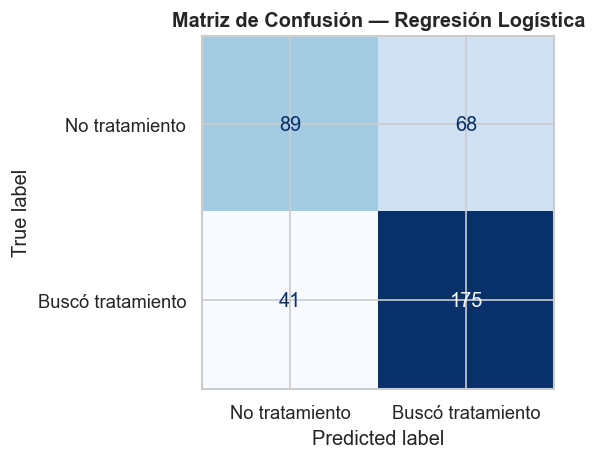

In [16]:
# Matriz de confusión — Regresión Logística
fig, ax = plt.subplots(figsize=(5, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr) # Cruza los valores reales y los que predijo el modelo
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No tratamiento', 'Buscó tratamiento'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Regresión Logística', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 5.2 Random Forest

Random Forest es un ensemble de múltiples árboles de decisión entrenados sobre subconjuntos aleatorios de los datos y features. Cada árbol vota por una clase, y se asigna la clase con más votos. Es robusto al ruido y permite conocer la importancia de cada variable.

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimator es la cantidad de arboles
rf.fit(X_train, y_train)  # No requiere escalado

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['No tratamiento (0)', 'Buscó tratamiento (1)']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Random Forest ===
                       precision    recall  f1-score   support

   No tratamiento (0)       0.66      0.53      0.59       157
Buscó tratamiento (1)       0.70      0.81      0.75       216

             accuracy                           0.69       373
            macro avg       0.68      0.67      0.67       373
         weighted avg       0.69      0.69      0.68       373

AUC-ROC: 0.7413


In [18]:
# Validación cruzada — Random Forest
cv_auc_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')

print(f'CV AUC (5-fold): {cv_auc_rf.mean():.4f} ± {cv_auc_rf.std():.4f}')
print(f'Scores por fold: {cv_auc_rf.round(4)}')

CV AUC (5-fold): 0.7291 ± 0.0326
Scores por fold: [0.7074 0.705  0.6955 0.7698 0.7677]


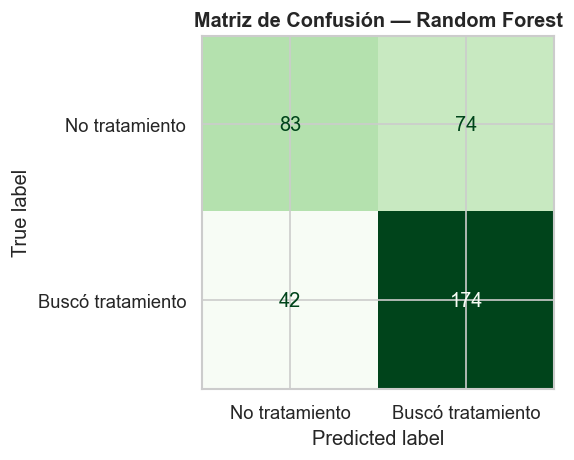

In [19]:
# Matriz de confusión — Random Forest
fig, ax = plt.subplots(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No tratamiento', 'Buscó tratamiento'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusión — Random Forest', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### Importancia de variables — Random Forest

Una ventaja de Random Forest es que entrega la importancia relativa de cada feature en la predicción.

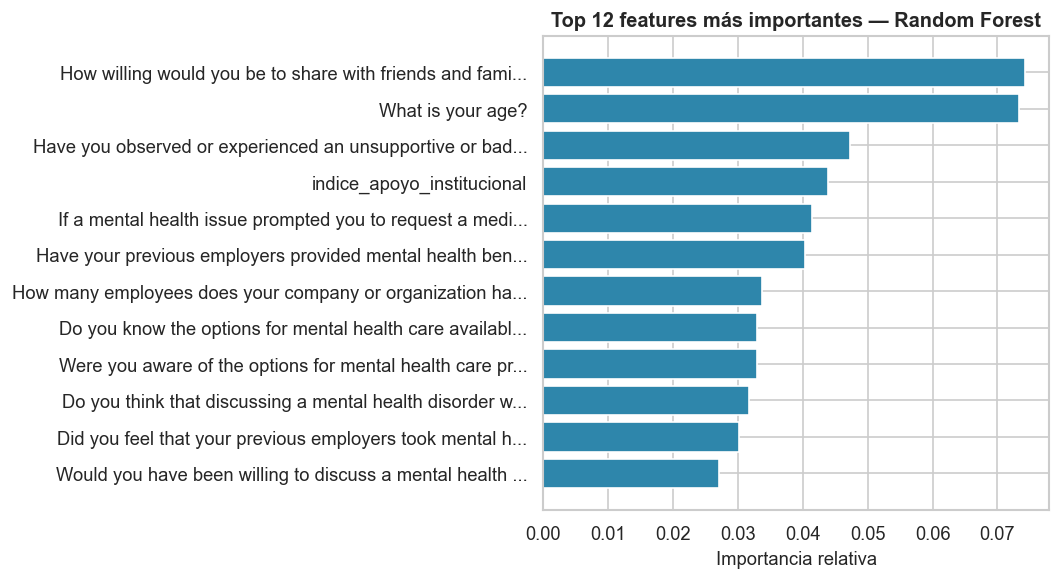

In [20]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

# Acortar nombres largos para el grafico
nombres_cortos = [
    n[:55] + '...' if len(n) > 55 else n
    for n in importancias.index
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(nombres_cortos[::-1], importancias.values[::-1], color='#2E86AB', edgecolor='white')
ax.set_xlabel('Importancia relativa', fontsize=11)
ax.set_title('Top 12 features más importantes — Random Forest', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 5.3 K-Nearest Neighbors (KNN)

KNN clasifica una nueva instancia buscando los K ejemplos más cercanos (por distancia Euclidiana) en el conjunto de entrenamiento y asignando la clase mayoritaria entre ellos. No tiene fase de entrenamiento explícita: almacena todos los datos y computa distancias en predicción.

In [21]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, y_train)

y_pred_knn = knn.predict(X_test_sc)
y_prob_knn = knn.predict_proba(X_test_sc)[:, 1]

print('=== K-Nearest Neighbors (K=7) ===')
print(classification_report(y_test, y_pred_knn, target_names=['No tratamiento (0)', 'Buscó tratamiento (1)']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_knn):.4f}')

=== K-Nearest Neighbors (K=7) ===
                       precision    recall  f1-score   support

   No tratamiento (0)       0.56      0.39      0.46       157
Buscó tratamiento (1)       0.64      0.78      0.70       216

             accuracy                           0.62       373
            macro avg       0.60      0.59      0.58       373
         weighted avg       0.61      0.62      0.60       373

AUC-ROC: 0.6610


In [22]:
# Validación cruzada — KNN
cv_auc_knn = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='roc_auc')

print(f'CV AUC (5-fold): {cv_auc_knn.mean():.4f} ± {cv_auc_knn.std():.4f}')
print(f'Scores por fold: {cv_auc_knn.round(4)}')

CV AUC (5-fold): 0.6637 ± 0.0328
Scores por fold: [0.6801 0.6028 0.6604 0.699  0.6763]


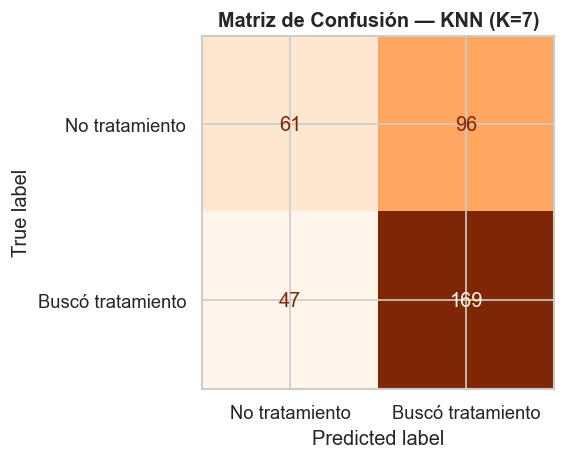

In [23]:
# Matriz de confusión — KNN
fig, ax = plt.subplots(figsize=(5, 4))
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No tratamiento', 'Buscó tratamiento'])
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Matriz de Confusión — KNN (K=7)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Comparación de modelos

### 6.1 Curvas ROC — los tres modelos

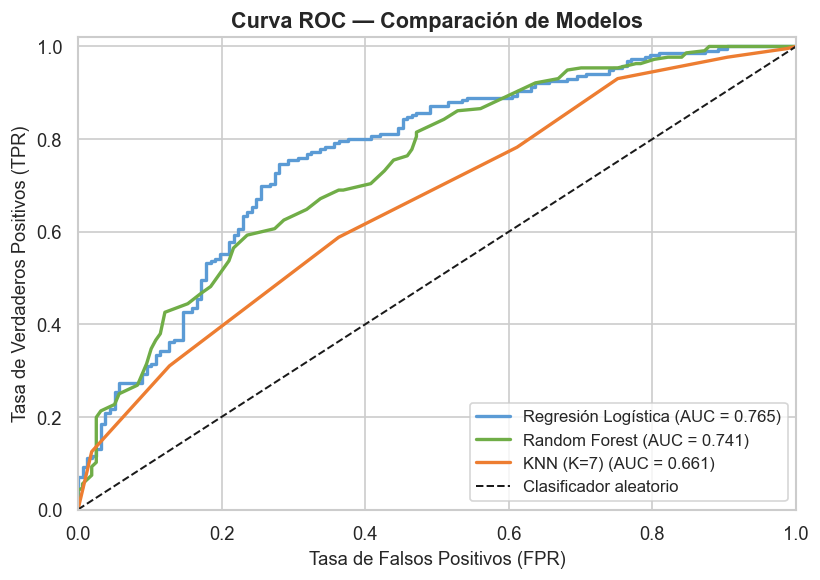

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

modelos_roc = [
    ('Regresión Logística', y_prob_lr, '#5B9BD5'),
    ('Random Forest',       y_prob_rf, '#70AD47'),
    ('KNN (K=7)',           y_prob_knn, '#ED7D31'),
]

for nombre, y_prob, color in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC — Comparación de Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

### 6.2 Tabla comparativa de métricas

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = {
    'Modelo': ['Regresión Logística', 'Random Forest', 'KNN (K=7)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_knn)
    ],
    'CV AUC (mean)': [
        cv_auc_lr.mean(),
        cv_auc_rf.mean(),
        cv_auc_knn.mean()
    ]
}

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados = df_resultados.round(2)
df_resultados

,Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV AUC (mean)
Modelo,,,,,,
Regresión Logística,0.71,0.72,0.81,0.76,0.76,0.72
Random Forest,0.69,0.70,0.81,0.75,0.74,0.73
KNN (K=7),0.62,0.64,0.78,0.70,0.66,0.66


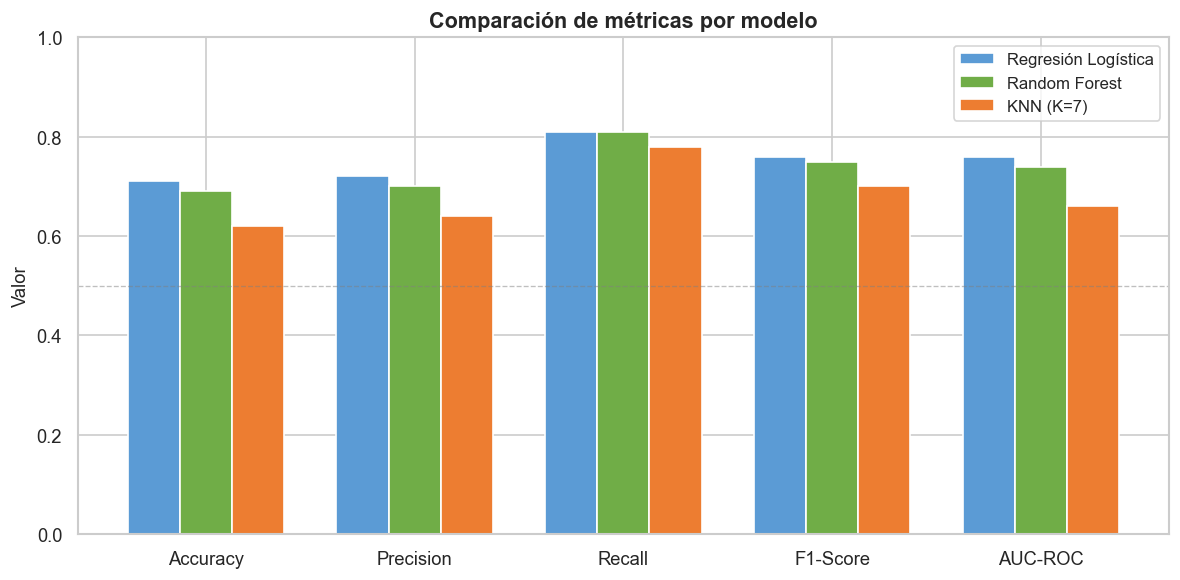

In [26]:
# Gráfico comparativo de métricas clave
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metricas))
width = 0.25
colores = ['#5B9BD5', '#70AD47', '#ED7D31']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (modelo, color) in enumerate(zip(['Regresión Logística', 'Random Forest', 'KNN (K=7)'], colores)):
    valores = [df_resultados.loc[modelo, m] for m in metricas]
    bars = ax.bar(x + i*width, valores, width, label=modelo, color=color, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylabel('Valor', fontsize=11)
ax.set_title('Comparación de métricas por modelo', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

---
## 7. Interpretación de resultados y limitaciones

### Análisis de errores

En el contexto de salud mental, los dos tipos de error tienen implicaciones distintas:
- **Falso Negativo (FN):** El modelo predice que la persona NO buscará tratamiento, pero sí lo haría. Este error tiene mayor costo si el objetivo fuera identificar personas en riesgo que necesitan intervención.
- **Falso Positivo (FP):** El modelo predice que la persona SÍ buscará tratamiento, pero no lo hará. Error menos crítico en este dominio.

Por eso se prioriza el **Recall de la clase 1** y el **AUC-ROC** sobre el accuracy simple.

### Conclusiones

| Modelo | Fortaleza | Debilidad |
|---|---|---|
| Regresión Logística | Interpretable, robusto, AUC competitivo | Asume relaciones lineales |
| Random Forest | Mayor accuracy y AUC, importancia de features | Menos interpretable directamente |
| KNN | Simple conceptualmente | Sensible a dimensionalidad, AUC menor |

**Modelo recomendado: Random Forest**, con AUC-ROC ~0.76 y el mejor balance de métricas. La variable más importante es el historial familiar de enfermedades mentales, seguida de la edad y la disposición a hablar con familia sobre salud mental.

### Limitaciones
- El dataset es de autoreporte y puede tener sesgo de respuesta
- Las encuestas fueron respondidas mayormente por personas de Norteamérica y Europa, limitando la generalización
- El desbalance moderado (58% vs 42%) se manejó con `stratify`, pero modelos más avanzados podrían usar SMOTE